In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    root_mean_squared_error,
    PredictionErrorDisplay
)

from src.config import DADOS_TRATADOS
from src.auxiliares import dataframe_coeficientes
from src.graficos import plot_coeficientes, plot_residuos

sns.set_theme(palette='bright')

RANDOM_STATE = 42

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int8   
 1   sexo              442 non-null    int8   
 2   imc               442 non-null    float32
 3   pressao_media     442 non-null    float32
 4   colesterol_total  442 non-null    int16  
 5   ldl               442 non-null    float32
 6   hdl               442 non-null    float32
 7   colesterol_hdl    442 non-null    float32
 8   triglicerides     442 non-null    float32
 9   glicose           442 non-null    int8   
 10  target            442 non-null    int16  
dtypes: float32(6), int16(2), int8(3)
memory usage: 13.5 KB


In [4]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=RANDOM_STATE
)

In [5]:
X_train.head() #observe o embaralhamento

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose
17,68,2,27.500000,111.0,214,147.000000,39.0,5.0,4.9416,91
66,46,2,24.700001,85.0,174,123.199997,30.0,6.0,4.6444,96
137,50,1,31.000000,123.0,178,105.000000,48.0,4.0,4.8283,88
245,41,1,23.100000,86.0,148,78.000000,58.0,3.0,4.0943,60
31,42,1,20.299999,71.0,161,81.199997,66.0,2.0,4.2341,81


In [6]:
X_test.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose
287,61,1,25.799999,90.000000,280,195.399994,55.0,5.0,4.9972,90
211,74,1,29.799999,101.000000,171,104.800003,50.0,3.0,4.3944,86
72,66,2,26.000000,91.000000,264,146.600006,65.0,4.0,5.5683,87
321,75,1,31.200001,117.669998,229,138.800003,29.0,7.9,5.7236,106
73,52,2,24.500000,94.000000,217,149.399994,48.0,5.0,4.5850,89


In [7]:
X_train.shape

(353, 10)

In [8]:
X_test.shape

(89, 10)

In [9]:
y_train.shape

(353,)

In [10]:
y_test.shape

(89,)

In [11]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

LinearRegression()

In [12]:
regressor.score(X_train, y_train)

0.5279194116592407

In [13]:
regressor.score(X_test, y_test)


0.4526023268699646

In [14]:
regressor.coef_

array([  0.1376898 , -23.064426  ,   5.846359  ,   1.197093  ,
        -1.2816849 ,   0.81114864,   0.6016509 ,  10.159533  ,
        67.1089    ,   0.20159864], dtype=float32)

In [15]:
regressor.intercept_

np.float32(-341.37747)

In [16]:
coefs = dataframe_coeficientes(regressor.coef_, X.columns)

coefs

,coeficiente
sexo,-23.064426
colesterol_total,-1.281685
idade,0.137690
glicose,0.201599
hdl,0.601651
ldl,0.811149
pressao_media,1.197093
imc,5.846359
colesterol_hdl,10.159533
triglicerides,67.108902


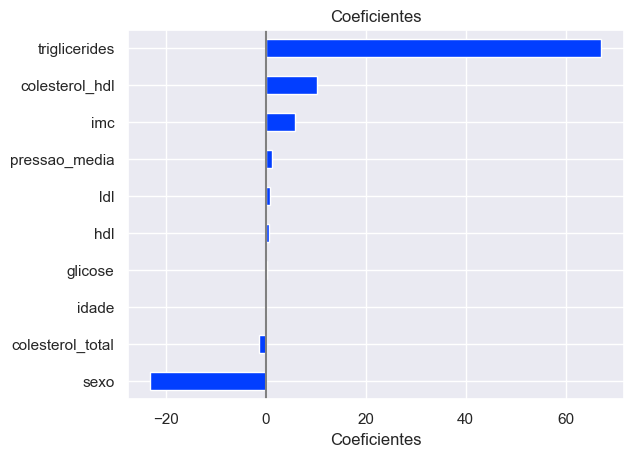

In [17]:
plot_coeficientes(coefs)

In [19]:
y_pred = regressor.predict(X_test)

y_pred

array([139.54721 , 179.5173  , 134.0386  , 291.4169  , 123.78958 ,
        92.17215 , 258.2322  , 181.33707 ,  90.22418 , 108.63364 ,
        94.13852 , 168.43503 ,  53.504913, 206.63083 , 100.129364,
       130.66672 , 219.53061 , 250.78024 , 196.36911 , 218.5751  ,
       207.35043 ,  88.48331 ,  70.43286 , 188.95914 , 154.88678 ,
       159.36179 , 188.31271 , 180.39108 ,  47.99054 , 108.97446 ,
       174.77884 ,  86.36398 , 132.95761 , 184.53824 , 173.83206 ,
       190.35837 , 124.41568 , 119.65103 , 147.95163 ,  59.054077,
        71.62332 , 107.68298 , 165.45386 , 155.0098  , 171.048   ,
        61.45758 ,  71.66675 , 114.96747 ,  51.579865, 167.57596 ,
       152.52307 ,  62.95569 , 103.49744 , 109.20752 , 175.64096 ,
       154.60297 ,  94.4169  , 210.74216 , 120.25659 ,  77.61597 ,
       187.93173 , 206.49338 , 140.63177 , 105.59677 , 130.70428 ,
       202.18515 , 171.13022 , 164.9143  , 124.72479 , 144.8103  ,
       181.99637 , 199.4136  , 234.21426 , 145.95673 ,  79.867

In [20]:
r2_score(y_test, y_pred)

0.4526023268699646

In [21]:
mean_absolute_error(y_test, y_pred)

42.794097900390625

In [22]:
mean_squared_error(y_test, y_pred)

2900.196044921875

In [23]:
root_mean_squared_error(y_test, y_pred)

53.85346984863281

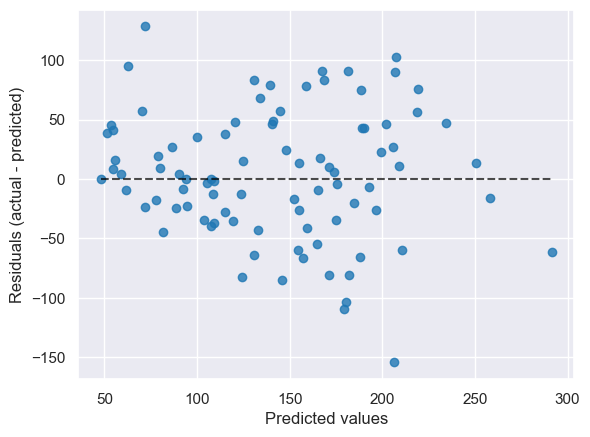

In [25]:
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred
)

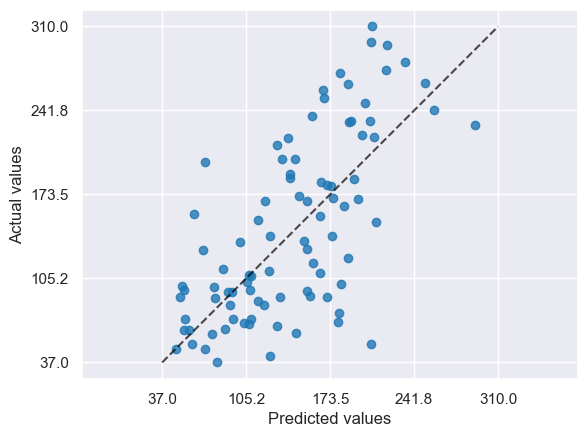

In [26]:
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred,
    kind='actual_vs_predicted'
)

<Axes: xlabel='target', ylabel='Count'>

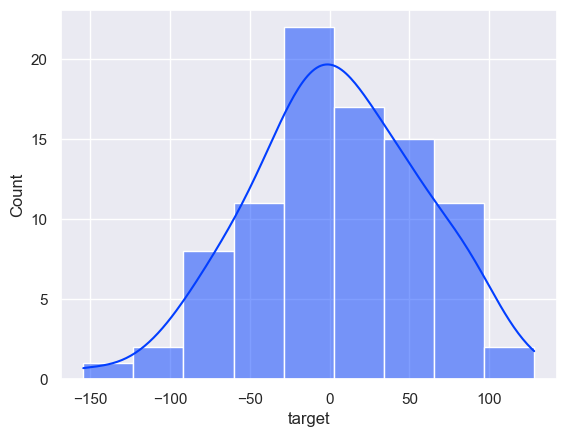

In [27]:
residuos = y_test - y_pred

sns.histplot(residuos, kde=True)

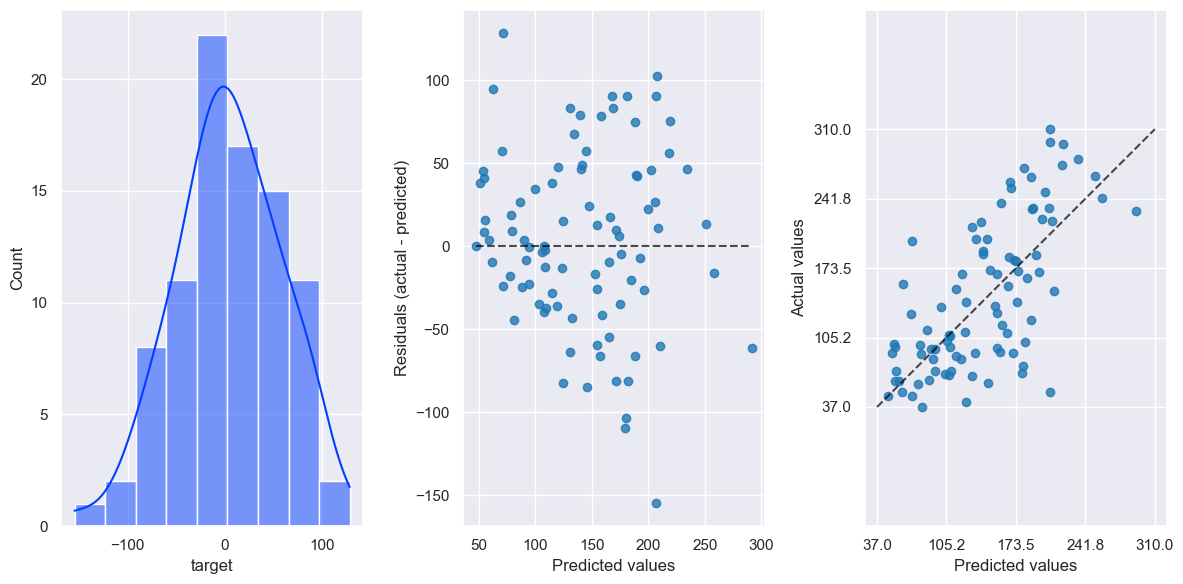

In [29]:
plot_residuos(y_test, y_pred)